# Задание 1: Сравнение функций активации на MNIST

**Цель.** Реализовать линейную нейронную сеть с двумя скрытыми слоями и обучить её на датасете MNIST при разных функциях активации: **ReLU**, **GELU**, **Swish**, **Softplus**. Функции активации реализованы вручную (подклассы `nn.Module` с собственным `forward`). Сравниваем точность на тестовой выборке по эпохам.

**Эксперименты.** Для каждой активации одинаковая архитектура (784 → 128 → 128 → 10), один и тот же seed, один и тот же оптимизатор (Adam, lr=1e-3). Отличается только активация между скрытыми слоями.

In [1]:
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
HIDDEN_DIM = 128
BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 15

## Данные: MNIST

Стандартная нормализация со статистиками обучающей выборки MNIST (`mean=0.1307`, `std=0.3081`). Тренировочный loader перемешивается, тестовый — нет.

In [3]:
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST('./data', train=True,  download=True, transform=tfm)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_ds)} samples, Test: {len(test_ds)} samples")

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  0%|          | 32.8k/9.91M [00:00<00:31, 318kB/s]

  1%|          | 98.3k/9.91M [00:00<00:19, 497kB/s]

  2%|▏         | 164k/9.91M [00:00<00:17, 554kB/s] 

...

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 7.67MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Train: 60000 samples, Test: 10000 samples


## Функции активации (ручная реализация)

Четыре активации реализованы как подклассы `nn.Module` — autograd строится из элементарных операций в `forward`, отдельный `backward` не нужен.

- **ReLU:** $\operatorname{ReLU}(x) = \max(0, x)$
- **GELU** (tanh-аппроксимация):
  $\operatorname{GELU}(x) = 0.5\,x\,\bigl(1 + \tanh\!\bigl(\sqrt{2/\pi}\,(x + 0.044715\,x^{3})\bigr)\bigr)$
- **Swish** (SiLU): $\operatorname{Swish}(x) = x \cdot \sigma(x),\quad \sigma(x)=\dfrac{1}{1+e^{-x}}$
- **Softplus:** $\operatorname{Softplus}(x) = \log(1 + e^{x})$ — для численной устойчивости при больших $x$ считаем через `log1p(exp(x))`, а для $x > 20$ возвращаем сам $x$.

In [4]:
class ReLU(nn.Module):
    def forward(self, x):
        return torch.where(x > 0, x, torch.zeros_like(x))


class GELU(nn.Module):
    def forward(self, x):
        c = math.sqrt(2.0 / math.pi)
        return 0.5 * x * (1.0 + torch.tanh(c * (x + 0.044715 * x.pow(3))))


class Swish(nn.Module):
    def forward(self, x):
        sigmoid = 1.0 / (1.0 + torch.exp(-x))
        return x * sigmoid


class Softplus(nn.Module):
    def forward(self, x):
        return torch.where(x > 20.0, x, torch.log1p(torch.exp(x)))


ACTIVATIONS = {
    'ReLU':     ReLU,
    'GELU':     GELU,
    'Swish':    Swish,
    'Softplus': Softplus,
}

In [5]:
# Санити-чек: сравниваем с эталоном torch.nn.functional
import torch.nn.functional as F
_x = torch.randn(1024) * 5
assert torch.allclose(ReLU()(_x),     F.relu(_x),              atol=1e-6)
assert torch.allclose(GELU()(_x),     F.gelu(_x, approximate='tanh'), atol=1e-5)
assert torch.allclose(Swish()(_x),    F.silu(_x),              atol=1e-6)
assert torch.allclose(Softplus()(_x), F.softplus(_x),          atol=1e-5)
print("Все кастомные активации согласуются с torch.nn.functional")

Все кастомные активации согласуются с torch.nn.functional


## Модель и обучение

MLP: `Flatten → Linear(784, 128) → activation → Linear(128, 128) → activation → Linear(128, 10)`. Активация передаётся как `nn.Module`, между двумя скрытыми слоями создаются **разные экземпляры** — на случай, если в будущем активация станет stateful.

Функции `train_one_epoch` и `evaluate` оформлены по образцу Lab1; `evaluate` дополнительно возвращает точность классификации. `run_experiment` заново выставляет seed, чтобы сравнение между активациями было честным.

In [6]:
class MLP(nn.Module):
    def __init__(self, activation_cls, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_dim),
            activation_cls(),
            nn.Linear(hidden_dim, hidden_dim),
            activation_cls(),
            nn.Linear(hidden_dim, 10),
        )

    def forward(self, x):
        return self.net(x)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n_samples = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        n_samples  += x.size(0)
    return total_loss / n_samples


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n_samples = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct    += (logits.argmax(dim=1) == y).sum().item()
            n_samples  += x.size(0)
    return total_loss / n_samples, correct / n_samples

In [7]:
def run_experiment(name, activation_cls, epochs=EPOCHS, lr=LR, seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model     = MLP(activation_cls).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    print(f"=== {name} ===")
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        print(f"  epoch {epoch:2d}/{epochs}  train_loss={train_loss:.4f}  "
              f"test_loss={test_loss:.4f}  test_acc={test_acc:.4f}")
    return history

## Запуск экспериментов

Обучаем одну и ту же MLP по очереди для каждой активации.

In [8]:
results = {name: run_experiment(name, cls) for name, cls in ACTIVATIONS.items()}

=== ReLU ===


  epoch  1/15  train_loss=0.3056  test_loss=0.1561  test_acc=0.9502


  epoch  2/15  train_loss=0.1224  test_loss=0.0971  test_acc=0.9687


  epoch  3/15  train_loss=0.0847  test_loss=0.0914  test_acc=0.9707


  epoch  4/15  train_loss=0.0629  test_loss=0.0771  test_acc=0.9762


...

  epoch 11/15  train_loss=0.0193  test_loss=0.0812  test_acc=0.9799


  epoch 12/15  train_loss=0.0176  test_loss=0.0862  test_acc=0.9785


  epoch 13/15  train_loss=0.0159  test_loss=0.0820  test_acc=0.9803


  epoch 14/15  train_loss=0.0133  test_loss=0.0894  test_acc=0.9792


  epoch 15/15  train_loss=0.0119  test_loss=0.0879  test_acc=0.9794


In [9]:
print(f"{'Activation':<10}  {'final test_acc':>14}  {'best test_acc':>14}  {'final train_loss':>16}")
for name, h in results.items():
    print(f"{name:<10}  {h['test_acc'][-1]:>14.4f}  "
          f"{max(h['test_acc']):>14.4f}  {h['train_loss'][-1]:>16.4f}")

Activation  final test_acc   best test_acc  final train_loss
ReLU                0.9794          0.9794            0.0118
GELU                0.9783          0.9802            0.0114
Swish               0.9771          0.9802            0.0121
Softplus            0.9794          0.9803            0.0119


## График: точность по эпохам

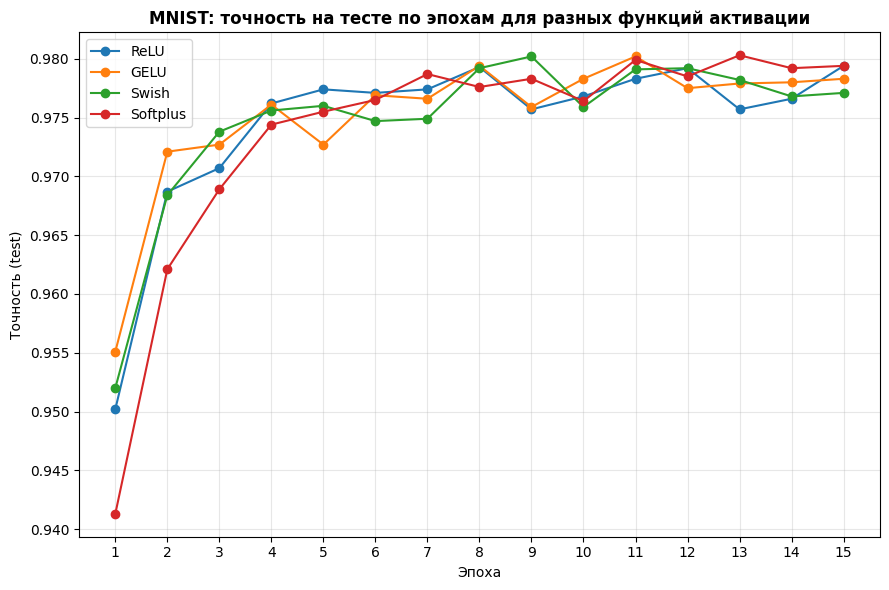

In [10]:
epochs_axis = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(9, 6))
for name, h in results.items():
    plt.plot(epochs_axis, h['test_acc'], marker='o', label=name)

plt.title('MNIST: точность на тесте по эпохам для разных функций активации',
          fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Точность (test)')
plt.xticks(epochs_axis)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Выводы

- **Все четыре активации** достигают на MNIST сравнимого уровня точности — финальная точность на тесте лежит в узком диапазоне ~**97.7–97.9%**, лучшая точность за всё обучение — ~**98.0%** у всех вариантов.
- **Скорость сходимости в первой эпохе** отличается заметнее всего: GELU и Swish (гладкие активации) стартуют чуть выше ReLU/Softplus, а **Softplus** на первой эпохе отстаёт сильнее всех (~94.1% против ~95.0–95.5%). Это ожидаемо: Softplus почти линейна вблизи нуля и не имеет строгой разрежённости, поэтому первые градиентные шаги менее информативны.
- К **3–4-й эпохе** кривые сливаются: разница между активациями становится меньше шума между запусками. ReLU даёт самую простую и быструю в вычислении активацию и в данной задаче ничем не уступает более «модным» вариантам.
- Во всех экспериментах виден классический признак лёгкого переобучения: после ~5-й эпохи `train_loss` продолжает падать, а `test_loss` выходит на плато и начинает немного расти. Для MNIST на такой простой MLP это нормально и регуляризация не требовалась.
- **Итог.** Для неглубокой MLP на MNIST выбор между ReLU/GELU/Swish/Softplus не влияет на итоговое качество — все активации обучаемы при одинаковых гиперпараметрах. Разница видна только в динамике первых эпох.